In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import sys

ROOT = Path().resolve().parent
sys.path.append(str(ROOT))

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid')

plt.rcParams['figure.figsize'] = (10, 6)

In [131]:
#Importación del tablon analitico
df_generacion = pd.read_parquet('../data/intermediate/tablon_analitico_importacion_generacion.parquet')
df_atmosferico = pd.read_parquet('../data/intermediate/tablon_analitico_importacion_atmosferico.parquet')
conteo_registros_generacion = pd.read_parquet('../data/intermediate/tablon_analitico_conteo_generacion.parquet')
conteo_registros_atmosferico = pd.read_parquet('../data/intermediate/tablon_analitico_conteo_atmosferico.parquet')

- Nuevas variables para los datasets principales para fase EDA.

In [132]:
#Añadimos nuevas variables temporales a los datasets desde src con add_time_features
from src.preprocessing import add_time_features

df_generacion = add_time_features(df_generacion)
df_atmosferico = add_time_features(df_atmosferico)

In [133]:
#Calculamos eficiencia para futuro uso en fase EDA
df_generacion['eficiencia'] = df_generacion['potencia_ac_kw'] / df_generacion['potencia_dc_kw'] * 100
df_generacion['eficiencia'] = df_generacion['eficiencia'].fillna(100)
df_generacion['eficiencia']= df_generacion['eficiencia'].clip(upper=100)

<Axes: >

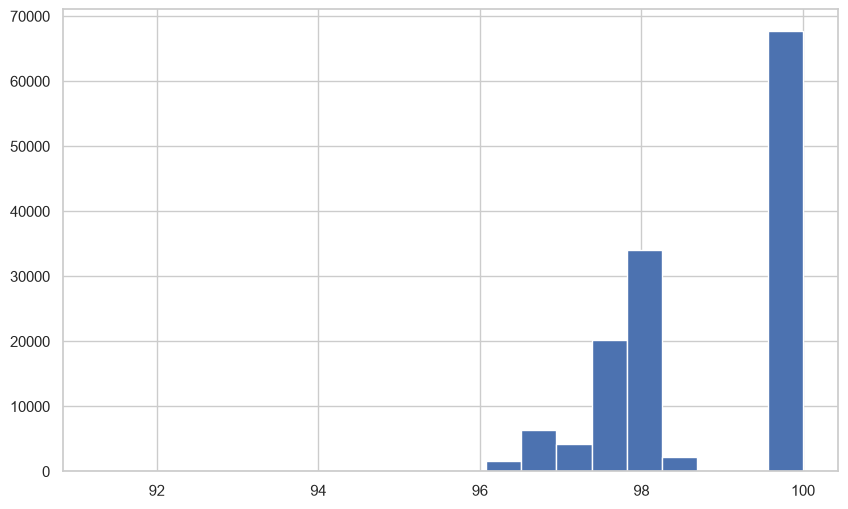

In [134]:
#comprovamos eficiencia
df_generacion['eficiencia'].hist(bins=20)

- Creación dataset combinado para fase EDA.

In [135]:
#dataset combinado para calcular ratios en fase EDA
df = pd.merge(
    df_generacion,
    df_atmosferico.drop(columns=["fecha", "mes", "dia", "hora", "minuto", "time"]),
    on=["fecha_hora", "id_planta"],
    how="left"
)

In [136]:
#Ordenamos las columnas de df
orden=['id_planta','id_inversor','id_sensor_meteorologico','fecha','mes',
       'dia','time','hora','minuto','irradiacion_wh_m2','temperatura_ambiente_c',
       'temperatura_modulo_c','potencia_dc_kw','eficiencia','potencia_ac_kw',
       'energia_diaria_kwh', 'energia_total_kwh']

df.set_index('fecha_hora', inplace=True)
df = df[orden]

- Creación dataset diario para contrastar metricas de forma correcta a nivel diario en fase EDA.

In [137]:
#Variable diaria 1: Irradiación acumulada diaria por planta
irradiacion_planta_diaria=(
    df_atmosferico.groupby(["id_planta", "fecha"])
    ['irradiacion_wh_m2']
    .sum()
    .reset_index(name='irradiacion_total_diaria')
)

In [121]:
#Variable diaria 2: Potencia diaria media por planta
potencia_media_diaria = (
    df_generacion
    .groupby(["id_planta", "fecha", "id_inversor"], as_index=False)
    .agg(
        potencia_dc_kw_media=("potencia_dc_kw", "mean"),
        potencia_ac_kw_media=("potencia_ac_kw", "mean"),
    )
)

In [138]:
#Variable diaria 3:Energia acumulada diaria por planta
energia_total_diaria = (
    df_generacion.groupby(['id_planta', 'fecha', 'id_inversor'])
    ['energia_diaria_kwh']
    .max()
    .groupby(["id_planta", "fecha"])
    .sum()
    .reset_index(name='energia_total_diaria_kwh')
)

In [140]:
#Variable diaria 4 y 5: conteo registros generacion y atmosferico
conteo_registros_generacion.rename(columns={
    "registros_observados": "reg_observados_gen",
    "registros_esperados": "reg_esperados_gen",
    "missing_timestamps": "reg_faltantes_gen",
    "pct_missing": "pct_faltantes_gen"}, inplace=True)
conteo_registros_atmosferico.rename(columns={
    "registros_observados": "reg_observados_atm",
    "registros_esperados": "reg_esperados_atm",
    "missing_timestamps": "reg_faltantes_atm",
    "pct_missing": "pct_faltantes_atm"},inplace=True)

conteo_registros_generacion = \
     conteo_registros_generacion[["id_planta", "id_inversor", "fecha", "reg_observados_gen","reg_esperados_gen", "reg_faltantes_gen", "pct_faltantes_gen"]]
conteo_registros_atmosferico = \
    conteo_registros_atmosferico[["id_planta", "fecha", "reg_observados_atm","reg_esperados_atm", "reg_faltantes_atm", "pct_faltantes_atm"]]

In [147]:
#Merge de variables diarias
df_diario = (
    irradiacion_planta_diaria
    .merge(potencia_media_diaria, on=['id_planta', 'fecha'], how='left')
    .merge(energia_total_diaria, on=['id_planta', 'fecha'], how='left')
    .merge(conteo_registros_atmosferico, on=["id_planta", "fecha"], how="left")
    .merge(conteo_registros_generacion, on=["id_planta", "fecha", "id_inversor"], how="left")
)

In [149]:
#Reordenamos variables
orden=['id_planta', 'fecha','id_inversor', 'irradiacion_total_diaria', 'energia_total_diaria_kwh',
       'potencia_dc_kw_media', 'potencia_ac_kw_media','reg_observados_atm','reg_esperados_atm','reg_faltantes_atm',
       'pct_faltantes_atm','reg_observados_gen','reg_esperados_gen','reg_faltantes_gen','pct_faltantes_gen']
df_diario = df_diario[orden]

In [150]:
#Variables adicionales a nivel diario (eficiencia y ratios)
df_diario['eficiencia_potencia_media'] = df_diario['potencia_ac_kw_media'] / df_diario['potencia_dc_kw_media'] * 100
df_diario['performance_ratio'] = df_diario['energia_total_diaria_kwh'] / df_diario['irradiacion_total_diaria'] / 1000
df_diario['ratio_potencia_dc_irradiacion'] = df_diario['potencia_dc_kw_media'] / df_diario['irradiacion_total_diaria']
df_diario['ratio_potencia_ac_energia'] = df_diario['energia_total_diaria_kwh'] / df_diario['potencia_ac_kw_media'] / 100

In [151]:
# Guardar df a parquet
df.to_parquet('../data/processed/tablon_analitico_combinado.parquet')
df_diario.to_parquet('../data/processed/tablon_analitico_diario.parquet')
df_generacion.to_parquet('../data/processed/tablon_analitico_generacion.parquet')
df_atmosferico.to_parquet('../data/processed/tablon_analitico_atmosferico.parquet')